# Project-Day Panel: Comment Sentiment Analysis

Longitudinal panel with one row per project per campaign day (day 0 = launch).
Cross-sectional controls are constant within project; update and comment
variables vary by day.

Primary outcome: **comment sentiment** (daily mean VADER compound), not log pledged amount.

Data prep (categories, pledged/goal transforms, launch dates, treatment,
sample filters) mirrors [`detective_did_analysis.ipynb`](detective_did_analysis.ipynb)
and lives in [`panel_common.py`](panel_common.py) + [`build_project_day_panel.py`](build_project_day_panel.py).

In [2]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------------ --------------------- 4.5/9.5 MB 21.1 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 19.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 19.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- --

In [3]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')


def repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / 'data').is_dir() and (p / 'src').is_dir():
            return p
        p = p.parent
    return Path.cwd().resolve()


ROOT = repo_root()
sys.path.insert(0, str(ROOT / 'src' / 'analysis'))

from build_project_day_panel import (
    build_project_day_panel,
    build_cross_sectional,
    load_baseline,
    load_comments,
    load_updates,
    save_outputs,
    summarize_data_setup,
    DEFAULT_BASELINE,
    DEFAULT_UPDATES,
    DEFAULT_COMMENTS,
    DEFAULT_OUTPUT_DIR,
)

PANEL_DIR = ROOT / DEFAULT_OUTPUT_DIR
PANEL_PARQUET = PANEL_DIR / 'project_day_panel.parquet'
PANEL_PKL = PANEL_DIR / 'project_day_panel.pkl'

BASELINE_PKL = ROOT / DEFAULT_BASELINE
UPDATES_CSV = ROOT / DEFAULT_UPDATES
COMMENTS_CSV = ROOT / DEFAULT_COMMENTS

REQUIRE_ANALYZED_UPDATES = True
REQUIRE_ANALYZED_COMMENTS = True
EXTREMES_ONLY = True

print(f'Repo root: {ROOT}')
print(f'Baseline: {BASELINE_PKL}')
print(f'Updates:  {UPDATES_CSV}')
print(f'Comments: {COMMENTS_CSV}')

Repo root: C:\Users\Ben\Documents\GitHub\crowdsourcing
Baseline: C:\Users\Ben\Documents\GitHub\crowdsourcing\data\processed\final_with_deberta_ai_score_20251003_151656.pkl
Updates:  C:\Users\Ben\Documents\GitHub\crowdsourcing\data\analysis\detective\all_updates_analyzed_detective.csv
Comments: C:\Users\Ben\Documents\GitHub\crowdsourcing\data\analysis\all_comments_analyzed.csv


## 1. Data Prep (same logic as detective DID)

Step-by-step setup so you can audit categories, controls, merges, and the
analysis sample before the panel is built.

In [4]:
# 1A. Load baseline campaigns and build cross-sectional controls
baseline = load_baseline(BASELINE_PKL)
print(f'Loaded {len(baseline):,} campaigns from baseline pickle')
print(baseline[['project_id', 'log_pledged_amount', 'log_goal', 'word_count', 'text_quality']].head())

Loaded 64,488 campaigns from baseline pickle
   project_id  log_pledged_amount  log_goal  word_count  text_quality
0   542949574            6.568078  6.216606         274      0.963504
1    76740313            8.111928  8.006701         160      0.981250
2  1118160310            4.943979  9.210440         571      0.989492
3  1978410442            3.599751  5.620401         258      0.988372
4  1368557852            8.946585  8.699681         704      0.941761


In [5]:
# 1B. Unified categories (KS + IG mappings -> category_unified)
print('category_unified')
print(baseline['category_unified'].value_counts())
print('\nLaunch date range:', baseline['launch_date'].min(), 'to', baseline['launch_date'].max())
print('Mean campaign length (days):', baseline['campaign_days'].mean())

category_unified
category_unified
Film_Music_Performance    14575
Other                     11240
Publishing_Writing         9461
Creative_Visual_Arts       7353
Technology_Hardware        7332
Food_Lifestyle             7036
Games_Toys                 5788
Community_Education        1703
Name: count, dtype: int64

Launch date range: 2020-10-31 00:00:00 to 2024-12-10 00:00:00
Mean campaign length (days): 33.903935615928546


In [6]:
# 1C. Load DeTeCtive updates and analyzed comments
updates = load_updates(UPDATES_CSV)
comments = load_comments(COMMENTS_CSV)

print(f'Updates:  {len(updates):,} rows, {updates.project_id.nunique():,} projects')
print(f'Comments: {len(comments):,} rows, {comments.project_id.nunique():,} projects')

setup_before = summarize_data_setup(baseline, updates, comments)
setup_before

Updates:  298,905 rows, 29,337 projects
Comments: 1,032,352 rows, 23,879 projects


,metric,value
0,baseline_projects,64488
1,updates_rows,298905
2,updates_projects,29337
3,comments_rows,1032352
4,comments_projects,23879
5,baseline_with_ai_density,28201
6,baseline_with_launch_date,64488


In [7]:
# 1D. Define analysis sample + High_AI treatment (top/bottom quartile extremes)
cross = build_cross_sectional(
    baseline,
    updates,
    comments,
    require_analyzed_updates=REQUIRE_ANALYZED_UPDATES,
    require_analyzed_comments=REQUIRE_ANALYZED_COMMENTS,
    extremes_only=EXTREMES_ONLY,
)

ai_q75 = cross.loc[cross['High_AI'] == 1, 'ai_density'].min()
ai_q25 = cross.loc[cross['High_AI'] == 0, 'ai_density'].max()

print(f'Analysis sample: {len(cross):,} projects')
print(f'AI density thresholds -> bottom 25%: <= {ai_q25:.3f} | top 25%: >= {ai_q75:.3f}')
print('\nTreatment counts:')
print(cross['High_AI'].value_counts().rename(index={0: 'Low_AI (bottom 25%)', 1: 'High_AI (top 25%)'}))
print('\nCategory breakdown in sample:')
print(cross['category_unified'].value_counts())

summarize_data_setup(baseline, updates, comments, cross)

2026-06-12 17:01:36,062 - INFO - Cross-sectional sample: 8562 projects (ai_q25=0.449, ai_q75=0.640)
Analysis sample: 8,562 projects
AI density thresholds -> bottom 25%: <= 0.449 | top 25%: >= 0.640

Treatment counts:
High_AI
Low_AI (bottom 25%)    4281
High_AI (top 25%)      4281
Name: count, dtype: int64

Category breakdown in sample:
category_unified
Publishing_Writing        1796
Technology_Hardware       1548
Games_Toys                1330
Other                     1258
Creative_Visual_Arts      1001
Film_Music_Performance     908
Food_Lifestyle             679
Community_Education         42
Name: count, dtype: int64


,metric,value
0,baseline_projects,64488
1,updates_rows,298905
2,updates_projects,29337
3,comments_rows,1032352
4,comments_projects,23879
5,baseline_with_ai_density,28201
6,baseline_with_launch_date,64488
7,analysis_sample_projects,8562
8,high_ai_projects,4281
9,low_ai_projects,4281


## 2. Build or Load Project-Day Panel

Expands each project to days `0 .. campaign_days` and merges daily update/comment
aggregates. Inactive days get zero counts and NaN sentiment/AI scores.

In [8]:
if PANEL_PARQUET.is_file():
    panel = pd.read_parquet(PANEL_PARQUET)
    cross_saved = pd.read_parquet(PANEL_DIR / 'project_cross_sectional.parquet')
    print(f'Loaded cached panel: {len(panel):,} rows, {panel.project_id.nunique():,} projects')
elif PANEL_PKL.is_file():
    panel = pd.read_pickle(PANEL_PKL)
    cross_saved = pd.read_pickle(PANEL_DIR / 'project_cross_sectional.pkl')
    print(f'Loaded cached panel (pkl): {len(panel):,} rows')
else:
    panel, cross_saved = build_project_day_panel(
        BASELINE_PKL,
        UPDATES_CSV,
        COMMENTS_CSV,
        require_analyzed_updates=REQUIRE_ANALYZED_UPDATES,
        require_analyzed_comments=REQUIRE_ANALYZED_COMMENTS,
        extremes_only=EXTREMES_ONLY,
        baseline=baseline,
        updates=updates,
        comments=comments,
    )
    save_outputs(panel, cross_saved, PANEL_DIR)
    print(f'Built panel: {len(panel):,} rows, {panel.project_id.nunique():,} projects')

panel.head(10)

2026-06-12 17:01:37,862 - INFO - Cross-sectional sample: 8562 projects (ai_q25=0.449, ai_q75=0.640)
2026-06-12 17:01:40,210 - INFO - Panel built: 272212 rows, 8562 projects, mean campaign length 30.8 days
2026-06-12 17:01:40,252 - WARNING - pyarrow not installed; saving as pickle instead of parquet
2026-06-12 17:01:40,732 - INFO - Saved panel to C:\Users\Ben\Documents\GitHub\crowdsourcing\data\analysis\panels
Built panel: 272,212 rows, 8,562 projects


,project_id,day,log_pledged_amount,log_goal,word_count,category_unified,launch_date,launch_year,launch_month,launch_quarter,...,text_quality_update_day,update_day_count,comment_sentiment_day,comment_day_count,update_day,comment_day,calendar_date,calendar_month,calendar_quarter,PostGPT_day
0,892294092,0,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,0.992481,1,NaN,0,1,0,2024-08-06,2024-08,2024Q3,1
1,892294092,1,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,0.991667,1,0.87335,2,1,1,2024-08-07,2024-08,2024Q3,1
2,892294092,2,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,NaN,0,0.69500,2,0,1,2024-08-08,2024-08,2024Q3,1
3,892294092,3,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,0.987234,1,0.68545,2,1,1,2024-08-09,2024-08,2024Q3,1
4,892294092,4,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,NaN,0,NaN,0,0,0,2024-08-10,2024-08,2024Q3,1
5,892294092,5,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,NaN,0,NaN,0,0,0,2024-08-11,2024-08,2024Q3,1
6,892294092,6,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,NaN,0,NaN,0,0,0,2024-08-12,2024-08,2024Q3,1
7,892294092,7,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,0.993939,1,NaN,0,1,0,2024-08-13,2024-08,2024Q3,1
8,892294092,8,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,NaN,0,0.35515,2,0,1,2024-08-14,2024-08,2024Q3,1
9,892294092,9,10.642182,8.987322,2386,Publishing_Writing,2024-08-06,2024,8,2024Q3,...,NaN,0,NaN,0,0,0,2024-08-15,2024-08,2024Q3,1


## 3. Descriptives

Projects: 8,562
Mean campaign length: 30.8 days
Share of project-days with a comment: 0.152
Share of project-days with an update: 0.119


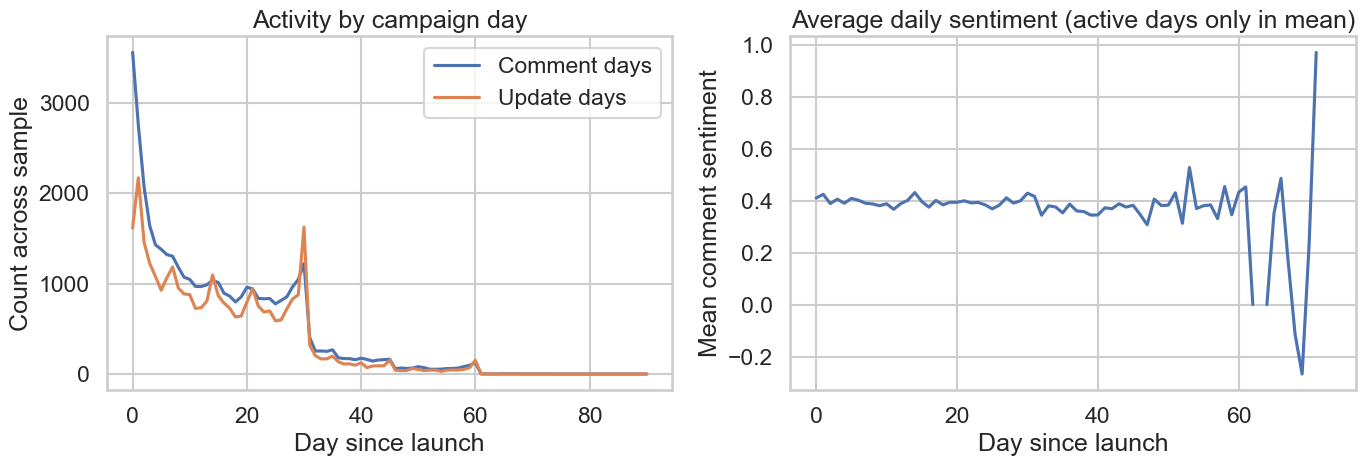

In [9]:
n_projects = panel['project_id'].nunique()
n_days = panel.groupby('project_id')['day'].max().mean()
share_comment_days = panel['comment_day'].mean()
share_update_days = panel['update_day'].mean()

print(f'Projects: {n_projects:,}')
print(f'Mean campaign length: {n_days:.1f} days')
print(f'Share of project-days with a comment: {share_comment_days:.3f}')
print(f'Share of project-days with an update: {share_update_days:.3f}')

activity = panel.groupby('day', as_index=False).agg(
    comment_days=('comment_day', 'sum'),
    update_days=('update_day', 'sum'),
    mean_sentiment=('comment_sentiment_day', 'mean'),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(activity['day'], activity['comment_days'], label='Comment days')
axes[0].plot(activity['day'], activity['update_days'], label='Update days')
axes[0].set_xlabel('Day since launch')
axes[0].set_ylabel('Count across sample')
axes[0].legend()
axes[0].set_title('Activity by campaign day')

axes[1].plot(activity['day'], activity['mean_sentiment'])
axes[1].set_xlabel('Day since launch')
axes[1].set_ylabel('Mean comment sentiment')
axes[1].set_title('Average daily sentiment (active days only in mean)')
plt.tight_layout()
plt.show()

## 4. Primary Models — Comment Sentiment as Outcome

Standard errors clustered at `project_id`. Continuous sentiment models use only
project-days with at least one comment.

In [10]:
sentiment_sample = panel.loc[panel['comment_day'] == 1].copy()
print(f'Sentiment level sample: {len(sentiment_sample):,} project-days')

base_controls = 'text_quality + log_goal + C(category_unified) + C(launch_year)'

sentiment_formula = f'comment_sentiment_day ~ High_AI * PostGPT_day + {base_controls}'
sentiment_model = smf.ols(sentiment_formula, data=sentiment_sample).fit(
    cov_type='cluster', cov_kwds={'groups': sentiment_sample['project_id']}
)
print('\n--- Daily comment sentiment ~ High_AI x PostGPT_day ---')
print(sentiment_model.summary())

Sentiment level sample: 41,379 project-days

--- Daily comment sentiment ~ High_AI x PostGPT_day ---
                              OLS Regression Results                             
Dep. Variable:     comment_sentiment_day   R-squared:                       0.024
Model:                               OLS   Adj. R-squared:                  0.024
Method:                    Least Squares   F-statistic:                     34.89
Date:                   Fri, 12 Jun 2026   Prob (F-statistic):           2.94e-98
Time:                           17:01:42   Log-Likelihood:                -13790.
No. Observations:                  41379   AIC:                         2.761e+04
Df Residuals:                      41363   BIC:                         2.775e+04
Df Model:                             15                                         
Covariance Type:                 cluster                                         
                                                    coef    std err          z 

In [11]:
count_formula = f'comment_day_count ~ High_AI * PostGPT_day + {base_controls}'
count_model = smf.ols(count_formula, data=panel).fit(
    cov_type='cluster', cov_kwds={'groups': panel['project_id']}
)
print('\n--- Daily comment count (full spine) ---')
print(count_model.summary())

binary_formula = f'comment_day ~ High_AI * PostGPT_day + {base_controls}'
binary_model = smf.ols(binary_formula, data=panel).fit(
    cov_type='cluster', cov_kwds={'groups': panel['project_id']}
)
print('\n--- Any comment that day (binary LPM) ---')
print(binary_model.summary())


--- Daily comment count (full spine) ---
                            OLS Regression Results                            
Dep. Variable:      comment_day_count   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     20.32
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           6.18e-55
Time:                        17:01:46   Log-Likelihood:            -6.9678e+05
No. Observations:              272212   AIC:                         1.394e+06
Df Residuals:                  272196   BIC:                         1.394e+06
Df Model:                          15                                         
Covariance Type:              cluster                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

## 5. Update-Side Predictors and text_quality Interaction

Test whether update AI density and grammar quality jointly predict daily comment sentiment.

In [12]:
update_sample = sentiment_sample.dropna(subset=['ai_score_update_day', 'text_quality_update_day'])
print(f'Update predictor sample: {len(update_sample):,} project-days')

update_formula = (
    'comment_sentiment_day ~ ai_score_update_day * text_quality_update_day '
    '+ update_day + text_quality + log_goal + C(category_unified)'
)
update_model = smf.ols(update_formula, data=update_sample).fit(
    cov_type='cluster', cov_kwds={'groups': update_sample['project_id']}
)
print('\n--- Comment sentiment ~ update AI x update text_quality ---')
print(update_model.summary())

interaction_coef = update_model.params.get('ai_score_update_day:text_quality_update_day', np.nan)
print(f'\nAI x text_quality interaction: {interaction_coef:.4f}')

Update predictor sample: 9,070 project-days

--- Comment sentiment ~ update AI x update text_quality ---
                              OLS Regression Results                             
Dep. Variable:     comment_sentiment_day   R-squared:                       0.030
Model:                               OLS   Adj. R-squared:                  0.029
Method:                    Least Squares   F-statistic:                     870.2
Date:                   Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                           17:01:50   Log-Likelihood:                -2310.6
No. Observations:                   9070   AIC:                             4647.
Df Residuals:                       9057   BIC:                             4740.
Df Model:                             12                                         
Covariance Type:                 cluster                                         
                                                    coef    std err        

## 6. Monthly Aggregation (Robustness)

Collapse to project-month means/sums for a coarser time index.

In [13]:
monthly = (
    panel.groupby(['project_id', 'calendar_month'], as_index=False)
    .agg(
        comment_sentiment_month=('comment_sentiment_day', 'mean'),
        comment_count_month=('comment_day_count', 'sum'),
        comment_days_month=('comment_day', 'sum'),
        ai_score_update_month=('ai_score_update_day', 'mean'),
        text_quality_update_month=('text_quality_update_day', 'mean'),
        High_AI=('High_AI', 'first'),
        text_quality=('text_quality', 'first'),
        log_goal=('log_goal', 'first'),
        category_unified=('category_unified', 'first'),
        launch_year=('launch_year', 'first'),
        PostGPT_month=('PostGPT_day', 'max'),
    )
)

monthly_sentiment = monthly.loc[monthly['comment_days_month'] > 0].copy()
monthly_formula = (
    'comment_sentiment_month ~ High_AI * PostGPT_month '
    '+ text_quality + log_goal + C(category_unified) + C(launch_year)'
)
monthly_model = smf.ols(monthly_formula, data=monthly_sentiment).fit(
    cov_type='cluster', cov_kwds={'groups': monthly_sentiment['project_id']}
)
print(f'Monthly panel: {len(monthly):,} project-months')
print(monthly_model.summary())

Monthly panel: 17,057 project-months
                               OLS Regression Results                              
Dep. Variable:     comment_sentiment_month   R-squared:                       0.056
Model:                                 OLS   Adj. R-squared:                  0.055
Method:                      Least Squares   F-statistic:                     38.14
Date:                     Fri, 12 Jun 2026   Prob (F-statistic):          7.24e-108
Time:                             17:01:50   Log-Likelihood:                -1337.6
No. Observations:                    10848   AIC:                             2707.
Df Residuals:                        10832   BIC:                             2824.
Df Model:                               15                                         
Covariance Type:                   cluster                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------

## 7. Future: pledge_amount_day

When Kicktraq daily funding data is available, merge `pledge_amount_day` onto
this panel and model within-project funding dynamics.

In [14]:
KICKTRAQ_PANEL = PANEL_DIR / 'project_day_panel_with_kicktraq.parquet'
if KICKTRAQ_PANEL.is_file():
    panel_funding = pd.read_parquet(KICKTRAQ_PANEL)
    funding_formula = (
        'pledge_amount_day ~ ai_score_update_day + comment_sentiment_day '
        '+ text_quality + log_goal + C(category_unified)'
    )
    funding_sample = panel_funding.dropna(subset=['pledge_amount_day'])
    funding_model = smf.ols(funding_formula, data=funding_sample).fit(
        cov_type='cluster', cov_kwds={'groups': funding_sample['project_id']}
    )
    print(funding_model.summary())
else:
    print('Kicktraq data not yet merged. Skipping pledge_amount_day models.')

Kicktraq data not yet merged. Skipping pledge_amount_day models.
